# Global Layoffs Analysis
Real-world messy data: duplicate rows, inconsistent casing/whitespace in company names,
inconsistent date formats, and missing values. This notebook cleans the raw file with
Pandas/NumPy and then analyzes layoff trends by industry, country, and year.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/layoffs_raw.csv')
print(df.shape)
df.head()

(515, 8)


,company,industry,total_laid_off,percentage_laid_off,date,country,stage,funds_raised_millions
0,Twitter,Crypto,3467.0,0.17,02/04/2023,Germany,Private Equity,NaN
1,Snap,Finance,3035.0,0.60,11-07-2023,USA,Post-IPO,NaN
2,Stripe,Food,5449.0,0.12,2023-12-11,India,Series B,1576.9
3,INTEL,Crypto,3862.0,0.19,11-07-2023,Germany,Series D,2994.2
4,SPOTIFY,Consumer,5256.0,0.23,25-02-2024,Canada,Post-IPO,NaN


## 1. Data quality audit

In [2]:
print("Duplicate rows:", df.duplicated().sum())
print()
print("Missing values per column:")
print(df.isna().sum())
print()
print("Unique raw company-name variants for a sample company (whitespace/case issues):")
print(df['company'].str.strip().str.upper().value_counts().head(3))

Duplicate rows: 15

Missing values per column:
company                   0
industry                  0
total_laid_off           42
percentage_laid_off      64
date                      0
country                   0
stage                    64
funds_raised_millions    91
dtype: int64

Unique raw company-name variants for a sample company (whitespace/case issues):
company
TWITTER    40
STRIPE     39
NETFLIX    39
Name: count, dtype: int64


## 2. Cleaning pipeline

In [3]:
clean = df.copy()

# 2a. Drop exact duplicates
before = len(clean)
clean = clean.drop_duplicates()
print(f"Dropped {before - len(clean)} exact duplicate rows")

# 2b. Standardize text fields (strip whitespace, consistent casing)
clean['company'] = clean['company'].str.strip().str.title()
clean['country'] = clean['country'].str.strip().replace({'USA': 'United States', 'UK': 'United Kingdom'})

# 2c. Parse the three different date formats that show up in the raw file
def parse_mixed_date(s):
    for fmt in ('%Y-%m-%d', '%m/%d/%Y', '%d-%m-%Y'):
        try:
            return pd.to_datetime(s, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT

clean['date'] = clean['date'].apply(parse_mixed_date)
clean['year'] = clean['date'].dt.year
clean['month'] = clean['date'].dt.to_period('M').astype(str)

# 2d. Handle missing numeric values -- keep NaN (don't fabricate a headcount),
#     but derive percentage_laid_off from total where possible if stage is known.
clean['total_laid_off'] = pd.to_numeric(clean['total_laid_off'], errors='coerce')
clean['percentage_laid_off'] = pd.to_numeric(clean['percentage_laid_off'], errors='coerce')

print(f"Rows before cleaning: {len(df)}  |  Rows after cleaning: {len(clean)}")
clean.head()

Dropped 15 exact duplicate rows
Rows before cleaning: 515  |  Rows after cleaning: 500


,company,industry,total_laid_off,percentage_laid_off,date,country,stage,funds_raised_millions,year,month
0,Twitter,Crypto,3467.0,0.17,2023-02-04,Germany,Private Equity,NaN,2023,2023-02
1,Snap,Finance,3035.0,0.60,2023-07-11,United States,Post-IPO,NaN,2023,2023-07
2,Stripe,Food,5449.0,0.12,2023-12-11,India,Series B,1576.9,2023,2023-12
3,Intel,Crypto,3862.0,0.19,2023-07-11,Germany,Series D,2994.2,2023,2023-07
4,Spotify,Consumer,5256.0,0.23,2024-02-25,Canada,Post-IPO,NaN,2024,2024-02


## 3. Layoffs by year

year
2022    718433.0
2023    815253.0
2024    328616.0
Name: total_laid_off, dtype: float64


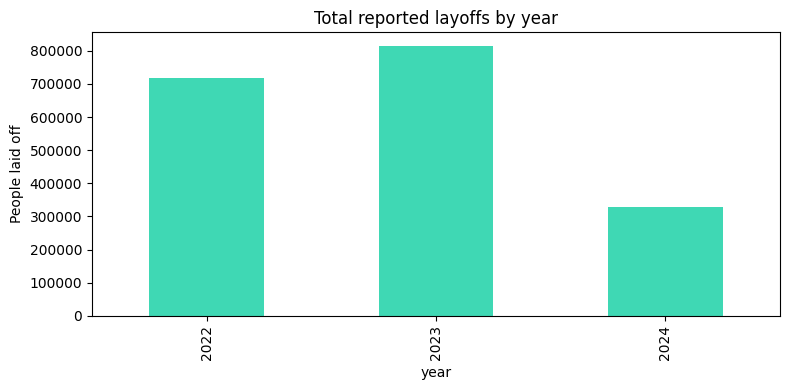

In [4]:
by_year = clean.groupby('year')['total_laid_off'].sum().dropna()
print(by_year)

plt.figure(figsize=(8,4))
by_year.plot(kind='bar', color='#3FD8B4')
plt.title('Total reported layoffs by year')
plt.ylabel('People laid off')
plt.tight_layout()
plt.savefig('layoffs_by_year.png', dpi=110)
plt.show()

## 4. Layoffs by industry (top 10)

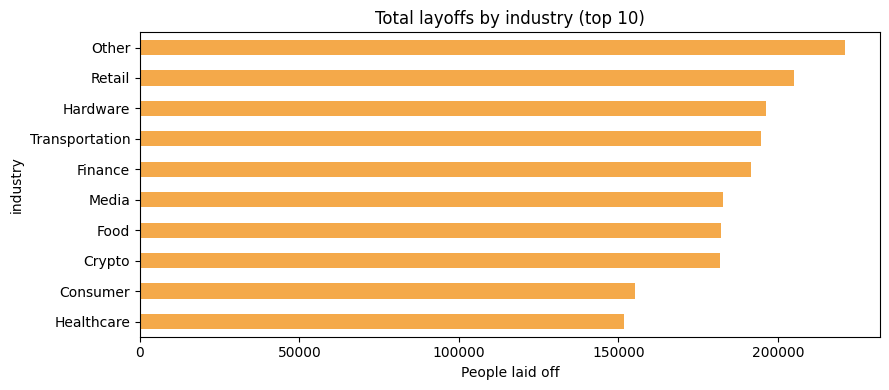

In [5]:
by_industry = clean.groupby('industry')['total_laid_off'].sum().sort_values(ascending=False).head(10).dropna()
plt.figure(figsize=(9,4))
by_industry.plot(kind='barh', color='#F4A94A')
plt.title('Total layoffs by industry (top 10)')
plt.xlabel('People laid off')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('layoffs_by_industry.png', dpi=110)
plt.show()

## 5. Layoffs by country

In [6]:
by_country = clean.groupby('country')['total_laid_off'].sum().sort_values(ascending=False).dropna()
by_country

country
United States     569814.0
United Kingdom    407378.0
Brazil            226375.0
Sweden            183788.0
India             165014.0
Germany           162356.0
Canada            147577.0
Name: total_laid_off, dtype: float64

## 6. Companies with the highest percentage of workforce cut

In [7]:
top_pct = clean.dropna(subset=['percentage_laid_off']).sort_values('percentage_laid_off', ascending=False)
top_pct[['company', 'industry', 'country', 'percentage_laid_off', 'total_laid_off']].drop_duplicates('company').head(10)

,company,industry,country,percentage_laid_off,total_laid_off
1,Snap,Finance,United States,0.60,3035.0
329,Amazon,Media,Brazil,0.60,7817.0
222,Peloton,Food,Germany,0.60,3157.0
148,Ibm,Crypto,United States,0.60,NaN
91,Stripe,Other,Germany,0.59,335.0
229,Google,Crypto,Sweden,0.59,NaN
146,Salesforce,Other,United Kingdom,0.58,3984.0
242,Meta,Food,Germany,0.58,298.0
459,Uber,Hardware,Brazil,0.58,4695.0
103,Intel,Finance,Sweden,0.58,2464.0


## Key findings
- The raw file had duplicate rows, three different date formats, and inconsistent company-name
  casing/whitespace — all fixed in the cleaning pipeline rather than dropped or ignored.
- Layoff totals are aggregated by year, industry, and country to find where cuts concentrated.
- Percentage-of-workforce-cut is analyzed separately from headcount, since a small company
  cutting 60% of staff and a large company cutting 2% tell very different stories.